<a href="https://colab.research.google.com/github/hmaiac-ops/MVP-MachineLearning-Analytics/blob/main/MVP_ML_Analytics_20261_Hamilton_Maia_Christovam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** _Hamilton Maia Christovam_  
**Matrícula:** _4052026000085_  
**Data:** _02/06/2026_  
**Dataset:** _Telco Customer Churn https://www.kaggle.com/datasets/blastchar/telco-customer-churn_  
**Tipo de problema:** _Classificação_  

---



## Checklist do MVP

Use este checklist antes da entrega.

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ok |
| Dataset descrito, com fonte, atributos e restrições | ok |
| Dataset carregado por URL pública ou fonte diretamente acessível | ok |
| Análise exploratória objetiva, conectada à modelagem | ok |
| Divisão adequada em treino/teste e, se aplicável, validação | ok |
| Prevenção de vazamento de dados | ok |
| Tratamentos de dados justificados | ok |
| Pipeline ou sequência reprodutível de pré-processamento | ok |
| Modelo baseline definido | ok |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ok |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ok |
| Avaliação com métricas coerentes com o problema | ok |
| Discussão de overfitting/underfitting, limitações e melhorias | ok |
| Código limpo, organizado e executável do início ao fim | ok |
| Conclusão conectada ao objetivo inicial | ok |



# 1. Definição do problema

## 1.1 Descrição do problema

Num setor de telecomunicações muito competitivo (por exemplo, hoje no Brasil temos apenas 3 grandes operadoras nacionais de telefonia móvel), o acompanhamento e ações de minimização de perda de clientes é fundamental para o negócio. O termo "churn" refere-se à perda de clientes, ou seja, quando um consumidor cancela seu contrato ou deixa de utilizar os serviços da empresa. Nesse mercado, o custo para adquirir um novo cliente é significativamente maior do que o custo para reter um cliente atual.

Qual o objetivo do modelo? Este modelo tem como objetivo apoiar a classificação preditiva. Ele deve analisar o comportamento histórico dos clientes (como tipo de contrato, tempo de permanência, serviços assinados e cobranças) para prever quais deles têm maior probabilidade de cancelar o serviço no futuro próximo.

Quem são os interessados? Os principais usuários desta solução seriam as equipes de Marketing e Retenção de Clientes, além de gestores de Customer Experience (CX). Com essas previsões em mãos, essas equipes podem agir de forma proativa, oferecendo descontos ou planos personalizados para os clientes identificados como "em risco" antes que eles tomem a decisão de sair.

Por que este problema é relevante? A relevância reside no impacto financeiro direto. Identificar padrões que levam ao churn permite que a empresa otimize seus investimentos em fidelização, reduza a perda de receita recorrente e melhore a satisfação geral da base de clientes.

## 1.2 Objetivo do MVP

 O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever o cancelamento de clientes (churn) a partir do dataset Telecom Customer Churn, comparando uma abordagem baseline com modelos candidatos para identificar a solução de melhor desempenho.


## 1.3 Tipo de problema

**Tipo escolhido:** _Classificação_

**Justificativa:** _Trata-se de um problema de classificação porque o objetivo é prever uma categoria/classe discreta (o cliente cancelará o serviço: "Sim" ou "Não")_



## 1.4 Premissas, hipóteses e critérios de sucesso


**Hipóteses iniciais:**
1. Hipótese 1: O uso de serviços adicionais, como suporte técnico e segurança online, atua como um fator de retenção, e clientes sem esses serviços têm maior probabilidade de cancelamento.
2. Hipótese 2: Clientes com contratos do tipo mensais apresentam uma propensão ao churn maior do que aqueles com contratos anuais.
3. Hipótese 3: Clientes com baixo tempo de permanência (tenure) na empresa apresentam uma probabilidade maior de churn do que clientes de longo prazo.

**Critérios de sucesso:**
- Métrica principal: F1-score, pensando em equilíbrio entre precisão e recall, tendo em mente que a base de churn tende a ser desbalanceada, com muito menos clientes que cancelam do que os que permanecem.
- Resultado mínimo esperado: Superar o baseline em pelo menos 20%.
- Restrição prática: Tempo de processamento - Na rotina da operação, o modelo precisaria rodar no início de cada mês para gerar a lista de risco e direcionar as ações preventivas. Embora a base utilizada nesse MVP seja enxuta, em um cenário real de telecomunicações lidamos com milhões de assinantes ativos. Com essas quantidades, o volume de dados cresce de forma exponencial, transformando o tempo de processamento e o custo de infraestrutura em fatores críticos.


# 2. Ambiente, bibliotecas e reprodutibilidade

**Bibliotecas:** Serão utilizadas bibliotecas padrão para manipulação de dados (Pandas, NumPy), visualização (Matplotlib, plotly.express) e o ecossistema Scikit-Learn para o fluxo de Machine Learning.

**Reprodutibilidade:** Uma semente (seed) fixa será definida para todas as operações que envolvem aleatoriedade.

Para este problema de classificação tabular com o dataset de Churn, a execução em CPU é suficiente, não sendo necessária a aceleração por GPU.

In [1]:
# === Setup básico e reprodutibilidade ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, make_scorer,
                             classification_report, ConfusionMatrixDisplay)
from scipy.stats import randint

SEED = 27 # Semente fixa para garantir reprodutibilidade dos experimentos



## 2.1 Dependências adicionais

Não foram necessárias dependências adicionais além das bibliotecas já disponíveis no ambiente padrão do Colab.

## 2.2 Funções auxiliares



In [20]:
def evaluate_classification(y_true, y_pred, zero_division=0):

   #Avalia o desempenho do modelo com foco na classe minoritária (Churn).

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label="Yes", zero_division=zero_division),
        "recall": recall_score(y_true, y_pred, pos_label="Yes", zero_division=zero_division),
        "f1": f1_score(y_true, y_pred, pos_label="Yes", zero_division=zero_division)
    }

    return metrics

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

**Nome do dataset:** _Telco Customer Churn_

**Link da fonte:** https://raw.githubusercontent.com/hmaiac-ops/MVP-ML-Analytics/refs/heads/main/WA_Fn-UseC_-Telco-Customer-Churn.csv


**Por que este dataset foi escolhido:** _Meu trabalho atual é em uma grande empresa de telecom. Trabalho na área comercial B2B e embora essa base seja referente a clientes pessoa física, esse dataset me interessou por ter alguma relação com o meu atual emprego e apresentar um problema que me atinge diretamente. Este conjunto de dados me proporciona um estudo interessante para problemas de classificação binária, contendo variáveis numéricas e categóricas. Ele permite demonstrar diversas etapas essenciais do fluxo de Machine Learning, como tratamento de dados desbalanceados e codificação de atributos._

**Restrições e condições consideradas:** _A principal condição técnica para a escolha foi a disponibilidade do dado em formato estruturado (CSV) e a viabilidade de carregamento remoto._

**Ética, privacidade e licença:** _O dataset é de domínio público e as informações foram anonimizadas pela fonte original (IBM), removendo qualquer dado sensível que pudesse identificar individualmente os clientes (PII - Personally Identifiable Information)._


## 3.2 Carga dos dados



In [3]:
# === Carga dos dados ===
url = "https://raw.githubusercontent.com/hmaiac-ops/MVP-ML-Analytics/refs/heads/main/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Realizar a conversão para numérico, transformando espaços em branco em NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(" ", np.nan))

df.head()



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3.3 Visão geral do dataset



In [4]:
print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

Formato do dataset: (7043, 21)

Tipos de dados:


,tipo
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [5]:
print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [6]:
print("\nDuplicatas:", df.duplicated().sum())



Duplicatas: 0


In [7]:
display(df.sample(5, random_state=SEED))

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4903,7330-WZLNC,Female,0,No,No,5,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,90.80,455.50,Yes
2695,0254-KCJGT,Male,0,Yes,No,52,Yes,Yes,DSL,Yes,...,Yes,Yes,No,Yes,One year,Yes,Credit card (automatic),81.40,4354.45,No
2184,4695-WJZUE,Female,1,No,No,2,Yes,Yes,Fiber optic,No,...,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,88.55,179.25,Yes
6024,5095-AESKG,Female,0,Yes,No,3,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Credit card (automatic),91.50,242.95,Yes
5861,9631-RXVJM,Male,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.25,677.90,No


## 3.4 Dicionário de dados

A base conta com 7.043 registros e 21 colunas, que mapeiam o perfil de consumo e o histórico de relacionamento dos assinantes.

| Coluna | Tipo | Descrição | Será usada no modelo? | Observação |
| :--- | :--- | :--- | :--- | :--- |
| **customerID** | Texto | Identificador único do cliente. | **Não** | Apenas um código de sistema, não traz valor para o treino do modelo. |
| **gender** | Categórico | Gênero do cliente. | **Sim** | Atributo demográfico básico, mantido para controle. |
| **SeniorCitizen** | Numérico | Idoso (1) ou não (0). | **Sim** | Indica a faixa etária do cliente. |
| **Partner** | Categórico | Possui parceiro/cônjuge. | **Sim** | Fator que ajuda a medir a estabilidade familiar do cliente. |
| **Dependents** | Categórico | Possui dependentes. | **Sim** | Ajuda a distinguir perfis familiares de individuais. |
| **tenure** | Numérico | Meses de permanência na empresa. | **Sim** | Preditor essencial: clientes novos têm risco de saída bem maior. |
| **PhoneService** | Categórico | Serviço telefônico. | **Sim** | Serviço base. |
| **MultipleLines** | Categórico | Múltiplas linhas telefônicas. | **Sim** | Indica o nível de uso da telefonia. |
| **InternetService** | Categórico | Tipo de serviço de internet. | **Sim** | Ponto crítico: tipo do serviço pode interferir na propensão a churn. |
| **OnlineSecurity** | Categórico | Suporte de segurança online. | **Sim** | Serviço extra que costuma segurar o cliente na base. |
| **OnlineBackup** | Categórico | Backup online. | **Sim** | Serviço extra que costuma segurar o cliente na base. |
| **DeviceProtection** | Categórico | Proteção de dispositivo. | **Sim** | Serviço extra que costuma segurar o cliente na base. |
| **TechSupport** | Categórico | Suporte técnico dedicado. | **Sim** | Serviço extra que costuma segurar o cliente na base. |
| **StreamingTV** | Categórico | Streaming de TV. | **Sim** | Indica o uso do portfólio de entretenimento. |
| **StreamingMovies** | Categórico | Streaming de filmes. | **Sim** | Indica o uso do portfólio de entretenimento. |
| **Contract** | Categórico | Tipo de contrato. | **Sim** | Ponto crítico: Contratos mensais ao invés de contratos com maior duração podem interferir na propensão a churn. |
| **PaperlessBilling** | Categórico | Fatura digital. | **Sim** | Mapeia a digitalização do cliente. |
| **PaymentMethod** | Categórico | Forma de pagamento. | **Sim** | Clientes que pagam via métodos manuais saem mais do que os em débito automático. |
| **MonthlyCharges** | Numérico | Valor mensal cobrado. | **Sim** | Ajuda a medir a sensibilidade do cliente ao preço. |
| **TotalCharges** | Numérico | Valor total cobrado. | **Sim** | Precisa de conversão de texto para número antes de rodar o modelo. |
| **Churn** | Categórico | O cliente cancelou o serviço? | **Alvo** | Prevê a classe binária: "Yes" (cancelou) ou "No" (permaneceu). |

# 4. Análise exploratória dos dados




In [8]:
# Define a variável alvo para os gráficos da EDA
TARGET = "Churn"

print("--- 4. ANÁLISE EXPLORATÓRIA DOS DADOS ---")

print("\n[1] Distribuição do Target (Churn):")
display(df[TARGET].value_counts(dropna=False).to_frame("contagem"))
display((df[TARGET].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("percentual"))

fig_target = px.histogram(df, x=TARGET, color=TARGET,
                          title="Distribuição da Variável Alvo (Churn)",
                          color_discrete_sequence=px.colors.qualitative.Set2)
fig_target.update_layout(xaxis_title="Cancelou o Serviço?", yaxis_title="Quantidade de Clientes", showlegend=False)
fig_target.show()

--- 4. ANÁLISE EXPLORATÓRIA DOS DADOS ---

[1] Distribuição do Target (Churn):


,contagem
Churn,
No,5174
Yes,1869


,percentual
Churn,
No,73.46
Yes,26.54


**Distribuição da Variável Alvo (Churn)**

**O que o gráfico indica:** A distribuição mostra que cerca de 26,5% da base cancelou o serviço (Yes). Como a grande maioria dos clientes permanece na empresa (No), temos um cenário de desbalanceamento de classes

**Influência na modelagem:** Modelos treinados sem ajuste focarão na classe majoritária (No), gerando alta acurácia geral mas falhando em prever o Churn real. Com isso em mente, será necessário aplicar técnicas de balanceamento.

In [9]:
# 4.2 Relação entre as Variáveis Categóricas Importantes e o Target
print("\n[2] Relação entre Variáveis Categóricas e o Churn:")

fig1 = px.histogram(df, x="Contract", color=TARGET, barmode="group",
                    title="Impacto da Variável 'Contract' no Churn",
                    color_discrete_sequence=px.colors.qualitative.Set2)
fig1.update_layout(xaxis_title="Tipo de Contrato", yaxis_title="Quantidade de Clientes", xaxis_tickangle=0)
fig1.show()



[2] Relação entre Variáveis Categóricas e o Churn:


**Impacto da Variável 'Contract' no Churn**

**O que o gráfico indica:** Clientes com contratos mensais (Month-to-month) têm uma propensão muito maior ao cancelamento do que clientes com contratos de 1 ou 2 anos.

**Influência na modelagem e Hipótese:**

 Hipótese: A ausência de uma barreira financeira ou contratual de saída facilita a perda do cliente. Essa variável categórica precisará ser codificada (via One-Hot Encoding) pois terá impacto relevante para os modelos de árvore de decisão.

In [10]:
# Segundo gráfico da seção 4.2: impacto do tipo de internet no Churn
fig2 = px.histogram(df, x="InternetService", color=TARGET, barmode="group",
                    title="Impacto da Variável 'InternetService' no Churn",
                    color_discrete_sequence=px.colors.qualitative.Set2)
fig2.update_layout(xaxis_title="Serviço de Internet (DSL, Fibra ou Não Possui)", yaxis_title="Quantidade de Clientes", xaxis_tickangle=0)
fig2.show()

**Impacto da Variável 'InternetService' no Churn**

**O que o gráfico indica:** Ao contrário do que imaginei no início, usuários de Fibra Ótica (Fiber optic) apresentam o maior volume proporcional de cancelamentos. Por outro lado, quem não possui internet (No), utilizando apenas telefonia fixa, quase nunca cancela.

**Influência na modelagem e Hipótese:**

 Hipótese: Pensei em algumas possíveis causas para esse comportamento. Entre elas, destaco: Concorrência forte buscando captura de clientes, preços mais altos do serviço impactando na permanência de cliente. A categoria No pode ter menor Churn por ser um serviço básico de telefonia já utilizado historicamente, mesmo antes da disponibilidade de serviços de internet. Essa variável terá peso crítico e passará por codificação categórica.

In [11]:
# 4.3 Análise da Variável Numérica Importante (tenure)

print("\n[3] Análise da Variável Numérica (tenure):")

fig3 = px.histogram(df, x="tenure", nbins=30,
                    title="Distribuição Geral do Tempo de Contrato (tenure)",
                    color_discrete_sequence=['#66c2a5'])
fig3.update_layout(xaxis_title="Meses de Contrato (tenure)", yaxis_title="Frequência de Clientes")
fig3.show()





[3] Análise da Variável Numérica (tenure):


**Distribuição do Tempo de Contrato (tenure)**

**O que o gráfico indica:** Clientes com maior tempo de casa resultam em churn muito menor e os primeiros meses de contrato são fundamentais para a permanência do cliente.

**Influência na modelagem:** Indica forte relação não-linear. Sendo uma variável contínua, precisará passar por padronização/escala (StandardScaler) para não distorcer modelos baseados em distância (como KNN) ou regularizações lineares, garantindo estabilidade numérica.

In [12]:
# GRÁFICO 4: Boxplot de Churn (Identificação de Padrões e Outliers)

print("\n[4] Identificação de Padrões e Outliers:")
fig4 = px.box(df, x=TARGET, y="tenure", color=TARGET,
              title="Distribuição do Tempo de Contrato (tenure) por Status de Churn",
              color_discrete_sequence=px.colors.qualitative.Set2)
fig4.update_layout(xaxis_title="Churn (Cancelou?)", yaxis_title="Meses de Contrato (tenure)")
fig4.show()


[4] Identificação de Padrões e Outliers:


**Distribuição do Tempo de Contrato (tenure) por Status de Churn**

**O que o gráfico indica:** O boxplot revela uma diferença clara no comportamento dos dois grupos. Os clientes que cancelaram o serviço (Churn = Yes) possuem um tempo de permanência muito baixo, concentrado nos meses iniciais do contrato. Já entre os clientes retidos (Churn = No), observamos um tempo de casa significativamente maior e mais estável.

**Influência na modelagem e Hipótese:**

 Hipótese: O risco de cancelamento é alto logo no início do relacionamento com o cliente. Após os primeiros meses, o risco diminui consideravelmente. Do ponto de vista técnico, como essa variável (tenure) separa tão bem quem fica de quem sai, modelos baseados em árvores(Random Forest, por exemplo) conseguem identificar pontos de corte bastante precisos para distinguir esses dois perfis.

## 4.1 Síntese da análise exploratória

**Síntese:**  
A análise exploratória de dados (EDA) permitiu mapear os comportamentos mais críticos associados à evasão de clientes, gerando direcionamentos fundamentais para as próximas fases do ciclo de ciência de dados.

**O target está balanceado?** Não. A classe minoritária (Churn = Yes) representa apenas 26,54% da base. Esse desbalanceamento direciona a estratégia de modelagem a evitar a métrica de Acurácia isolada, focando em Recall e F1-Score, além de exigir ajustes de peso de classe (class_weight='balanced') no treinamento dos modelos.

**Existem valores ausentes ou outliers relevantes?** Não foram identificados valores nulos ou ausentes nas variáveis principais. O comportamento da variável tenure se manteve dentro do esperado para o negócio (0 a 72 meses), e o Boxplot confirmou a ausência de outliers, eliminando a necessidade de aplicar técnicas de remoção de registros.

**Há variáveis com escala muito diferente?** Sim. Enquanto as variáveis preditoras categóricas serão transformadas em colunas binárias (0 ou 1) após o One-Hot Encoding, a variável contínua tenure apresenta valores que chegam até 72. Para evitar que algoritmos deem peso desproporcional ao tempo de casa, será implementada a padronização via StandardScaler no pipeline de pré-processamento.

**Há categorias raras?** Não. As categorias, como os tipos de contrato (mensal, anual ou bianual) e as opções de internet (DSL, fibra ou sem serviço), estão bem representadas na base de dados. Essa distribuição equilibrada dá segurança ao modelo, pois reduz o risco de overfitting causado pela falta de dados em algum grupo específico.

**Existem padrões que sugerem quais modelos podem funcionar melhor?** Os padrões mapeados são fortemente marcados por regras de segmentação claras (ex: contratos mensais + fibra ótica = alto risco de Churn rápido; contratos longos + tempo de casa alto = baixíssimo risco). Esse comportamento indica que modelos baseados em conjuntos de árvores (Random Forest, Gradient Boosting ou XGBoost) tendem a apresentar bom desempenho, pois conseguem capturar essas interações e quebras categóricas de forma nativa e não-linear.

**Algum resultado da EDA mudou sua estratégia de pré-processamento ou modelagem?** Sim. A descoberta de que os clientes de Fibra Ótica cancelam mais do que os de DSL mudou a perspectiva inicial de negócio. Tecnicamente, isso reforçou a necessidade de manter a integridade da coluna InternetService sem agrupamentos simplistas. Além disso, o forte impacto do tempo de casa nos meses iniciais (tenure baixo) validou que essa variável, junto com o tipo de contrato, deve ser tratada como recurso prioritário na validação dos modelos.

# 5. Preparação dos dados e divisão treino/teste

Nesta etapa do projeto, separei os dados em treino e teste. Essa divisão é fundamental para garantir que o modelo aprenda os padrões de churn com um conjunto de exemplos, enquanto reservei uma amostra 'cega' para validar se ele realmente consegue generalizar o conhecimento para clientes novos. A justificativa detalhada das escolhas está na seção 5.1.



In [13]:
# === Configuração do problema ===

# Contexto do problema — mantido para documentação
PROBLEM_TYPE = "classificação"

# Coluna a excluir da matriz de features (ID sem valor preditivo)
ID_COLUMNS = ["customerID"]

DROP_COLUMNS = []

assert TARGET in df.columns, f"Defina um TARGET válido. '{TARGET}' não encontrado."

columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS)
columns_to_exclude.add(TARGET)

features = [c for c in df.columns if c not in columns_to_exclude]

print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features que serão utilizadas:", len(features))
print("Features selecionadas:", features)



Tipo de problema: classificação
Target: Churn
Número de features que serão utilizadas: 19
Features selecionadas: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [14]:
# === Divisão dos dados em Treino e Teste ===
X = df[features].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("Divisão concluída com sucesso:")
print(f"X_train (Treino): {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test  (Teste) : {X_test.shape} | y_test : {y_test.shape}")

Divisão concluída com sucesso:
X_train (Treino): (5634, 19) | y_train: (5634,)
X_test  (Teste) : (1409, 19) | y_test : (1409,)


## 5.1 Justificativa da divisão

A estratégia adotada para a validação do modelo e segmentação do conjunto de dados foi o Holdout com amostragem estratificada, utilizando a proporção de 80% para o conjunto de treinamento e 20% para o conjunto de teste.  Abaixo, justifico essa escolha com base nas características do problema e nos desafios do dataset Telco Customer Churn.

**Por que usar holdout**
Escolhi a estratégia de Holdout porque o nosso problema de Churn é transversal. Como os dados representam uma fotografia estática do comportamento do cliente, e não uma série temporal com dependência de datas, não precisamos de divisões cronológicas complexas.

**Estratégia Complementar:**

Embora tenha reservado o Holdout para garantir um conjunto de teste 'cego' e definitivo, optei por utilizar a Validação Cruzada (Cross-Validation) durante o ajuste de hiperparâmetros. O uso do StratifiedKFold durante a busca de hiperparâmetros garante que o modelo seja avaliado de forma consistente em diferentes folds. Isso evita vícios de seleção e torna o ajuste dos parâmetros muito mais confiável para o nosso caso de uso.

**A proporção treino/teste faz sentido para o tamanho do dataset?**
Dividir a base em 80% para treino e 20% para teste é uma escolha adequada para o volume de dados do dataset (mais de 7.000 registros). Com os 80% do treino, o modelo ganha exemplos suficientes para aprender bem as relações entre as variáveis. Já os 20% restantes garantem uma amostra sólida para avaliarmos o desempenho final com segurança, mantendo as métricas de teste consistentes e confiáveis.

**Foi necessário estratificar as classes?**

Sim. Como vimos na análise exploratória, a base é desbalanceada: cerca de 26,5% dos clientes deram Churn e 73,5% não. Sem esse cuidado, uma divisão aleatória poderia, por sorte ou azar, deixar nosso conjunto de teste com poucos exemplos de churn, o que mascararia a real capacidade do modelo de detectar clientes em risco. A estratificação garante que ambos os conjuntos (treino e teste) mantenham essa proporção fiel da base, tornando a nossa validação muito mais segura e livre de distorções.

**Como a divisão evita vazamento de dados?**

A separação treino/teste foi realizada logo após a limpeza de IDs, garantindo o isolamento total dos dados antes de qualquer transformação.O conjunto de teste é aplicado apenas no final, simulando um ambiente real onde o modelo encontra dados novos e desconhecidos, o que garante uma avaliação honesta da sua performance.

# 6. Pré-processamento e pipeline

Nesta etapa, criei um pipeline utilizando o Scikit-Learn para organizar todo o tratamento dos dados. Usei um ColumnTransformer para agrupar as transformações matemáticas e a engenharia de atributos. Isso garante que o fluxo seja sempre o mesmo: aprendemos as regras apenas com os dados de treino e aplicamos essas mesmas transformações nos dados de teste e em novos dados, evitando qualquer erro no fluxo de trabalho.

In [15]:
print("--- 6. PRÉ-PROCESSAMENTO E PIPELINE ---")

# Separação de colunas por tipo
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

# pipeline numérico: mediana é mais robusta a outliers que a média
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# pipeline categórico: drop='first' evita redundância
categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first"))
])

# Centraliza todas as transformações em um único objeto
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ],
    remainder="drop" # descarta colunas que não foram mapeadas
)

print("-> Colunas numéricas:", num_cols)
print("-> Colunas categóricas:", cat_cols)


--- 6. PRÉ-PROCESSAMENTO E PIPELINE ---
-> Colunas numéricas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
-> Colunas categóricas: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 6.1 Decisões de pré-processamento

Defini como tratar cada tipo de dado com base no que aprendi na análise exploratória e nas premissas que os modelos de aprendizado de máquina exigem para funcionar bem.

**Por que usei média/mediana/moda para imputação?**

* Variáveis Numéricas: Usei a mediana para preencher valores ausentes via SimpleImputer. Como a mediana é resistente a valores extremos (outliers), ela preserva melhor a distribuição original dos dados, evitando distorções que poderiam prejudicar o modelo.

* Variáveis Categóricas: Para as colunas de texto, optei por preencher com a categoria mais frequente (moda). Essa é uma forma segura de manter a consistência do dataset sem criar categorias falsas ou introduzir ruídos no treino.

**Por que padronizei ou normalizei os dados?**
Apliquei o StandardScaler para padronizar as variáveis numéricas. Como vi na análise exploratória, elas estão em escalas muito diferentes: o tenure vai de 0 a 72, enquanto as cobranças chegam aos milhares. Se eu não padronizasse, modelos que calculam distâncias (como KNN ou SVM) ou que usam regularização ficariam 'confusos', dando um peso artificial muito maior para as variáveis com números grandes. O Z-score resolve isso, colocando todo mundo na mesma escala (média 0 e variância 1), o que ajuda o modelo a aprender de forma equilibrada

**Quais variáveis foram removidas e por quê?**
Removi a coluna customerID logo no início, pois, como é apenas um identificador alfanumérico, ela não traz nenhuma informação útil para prever o churn.

**Criei novas variáveis? Elas estariam disponíveis no momento real da previsão?**
Nesta etapa, não criei novas variáveis manualmente.

**Disponibilidade e Validação:**
Todas as variáveis que usei já estão disponíveis no CRM e no sistema de faturamento da empresa. Isso é fundamental, pois garante que o modelo terá acesso aos dados em tempo real, sem risco de usar informações que só aparecem depois que o cliente já deu Churn. Além disso, usei o drop='first' no OneHotEncoder para evitar a redundância de variáveis, o que deixa o modelo muito mais estável

# 7. Baseline e modelos candidatos

Nesta etapa, defini as estratégias de modelagem para prever o churn. Comecei criando um baseline para ter um ponto de comparação e, depois, escolhi dois modelos com lógicas diferentes: um linear e um baseado em árvores de decisão. Isso ajuda a ver qual abordagem lida melhor com os padrões dos nossos dados.

In [16]:
print("--- 7. BASELINE E MODELOS CANDIDATOS ---")

# Baseline: sempre chuta a classe mais frequente como referência mínima
baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
])

# Modelos candidatos: Regressão Logística e Random Forest
# class_weight='balanced' ajusta o treino para lidar com o desbalanceamento
candidates = {
    "LogisticRegression": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced'))
    ]),
    "RandomForest": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(random_state=SEED, class_weight='balanced'))
    ])
}

print("Baseline configurado:", type(baseline.named_steps['model']).__name__)
print("Modelos candidatos:", list(candidates.keys()))


--- 7. BASELINE E MODELOS CANDIDATOS ---
Baseline configurado: DummyClassifier
Modelos candidatos: ['LogisticRegression', 'RandomForest']


## 7.1 Justificativa dos modelos

Escolhi esses algoritmos pensando tanto no que descobri sobre os dados na análise exploratória quanto nas necessidades de negócio do nosso problema de churn.

**O baseline escolhido é coerente?**
Sim, usei o DummyClassifier como baseline baseando-me na classe mais frequente. Como vimos na análise exploratória, 73,46% dos clientes não cancelam o serviço. Esse baseline funciona como uma 'regra de negócio ingênua' que assume que ninguém sai. A partir de agora, qualquer modelo que eu treinar precisa superar essa referência, especialmente nas métricas de Recall e F1-Score; só assim provaremos que ele realmente aprendeu padrões nos dados em vez de apenas chutar a classe majoritária.

**Os modelos candidatos são adequados ao tipo e tamanho dos dados?**
Considerando que nosso dataset tem cerca de 7.000 registros e uma mistura de variáveis, escolhi dois modelos complementares:

* Regressão Logística: É um modelo rápido, estável e ótimo para começar. Além de classificar, ele me ajuda a entender o peso de cada variável na decisão final, o que é muito útil para explicar o resultado para o negócio.

* Random Forest: Como o dataset apresenta relações complexas — por exemplo, quando o risco de churn aumenta só para clientes com contrato mensal e fibra óptica ao mesmo tempo, esse modelo é ideal. Por ser um ensemble de árvores, ele captura essas interações não-lineares muito melhor do que um modelo linear simples.

**Algum modelo exige escala, encoding ou tratamento específico?**

* A Regressão Logística exige cuidados extras: apliquei padronização e removi colunas redundantes via pipeline para garantir estabilidade matemática.

* O Random Forest é naturalmente mais robusto a escalas diferentes, facilitando o treinamento após a conversão das variáveis categóricas.

* Em ambos, ativei o class_weight='balanced'. Como temos poucos casos de churn, esse ajuste força o modelo a tratar a classe 'Yes' com a mesma importância da classe majoritária, melhorando nossa capacidade de detectar quem realmente vai sair.

**Há alguma restrição de interpretabilidade, tempo ou custo computacional?**
Treinar os modelos é rápido e não gera custos relevantes, o que nos dá liberdade para testar diferentes abordagens. A ideia aqui é entender o equilíbrio entre interpretabilidade e performance: a Regressão Logística traduz o risco em números diretos para o negócio, enquanto o Random Forest captura padrões complexos que um modelo linear pode perder. Analisar os dois lado a lado nos dirá se o ganho de performance justifica a complexidade


# 8. Treinamento e avaliação inicial

Nesta etapa, treinei o baseline e os modelos candidatos usando apenas os dados de treino. Depois, fiz as predições no conjunto de teste, que o modelo nunca tinha visto antes, para avaliar o desempenho real. Os resultados estão consolidados na tabela abaixo.

In [17]:
print("--- 8. TREINAMENTO E AVALIAÇÃO INICIAL ---")

# Lista para consolidar os resultados de cada modelo
results_list = []

# Treinamento do baseline
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)

metrics_base = evaluate_classification(y_test, y_pred_base, zero_division=0)
results_list.append({
    "Modelo": "Baseline (Most Frequent)",
    "Acurácia": metrics_base["accuracy"],
    "Precisão": metrics_base["precision"],
    "Recall": metrics_base["recall"],
    "F1-Score": metrics_base["f1"]
})

# Treinamento e avaliação dos modelos candidatos
for name, pipe in candidates.items():

    # Ajusta o pipeline ao treino e prevê no teste
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    # Armazena métricas focando na classe alvo "Yes"
    metrics = evaluate_classification(y_test, y_pred)
    results_list.append({
        "Modelo": name,
        "Acurácia": metrics["accuracy"],
        "Precisão": metrics["precision"],
        "Recall": metrics["recall"],
        "F1-Score": metrics["f1"]
    })


df_results = pd.DataFrame(results_list)

print("\n" + "="*60)
print("TABELA COMPARATIVA DE DESEMPENHO INICIAL")
print("="*60)
display(df_results.round(4))

--- 8. TREINAMENTO E AVALIAÇÃO INICIAL ---

TABELA COMPARATIVA DE DESEMPENHO INICIAL


,Modelo,Acurácia,Precisão,Recall,F1-Score
0,Baseline (Most Frequent),0.7346,0.0000,0.0000,0.0000
1,LogisticRegression,0.7473,0.5157,0.7888,0.6237
2,RandomForest,0.7878,0.6289,0.4893,0.5504


## 8.1 Análise dos resultados iniciais

Agora, vou analisar os resultados para entender o quanto nossos modelos realmente conseguiram aprender sobre o churn da empresa.

**O modelo superou o baseline?**
Sim, ambos os modelos superaram muito bem o baseline. Como o DummyClassifier apenas chuta a classe mais frequente, ele não detectou nenhum caso de churn (Recall e F1-Score zerados), confirmando que regras estáticas não funcionam aqui. Por outro lado, a Regressão Logística e o Random Forest conseguiram identificar padrões reais nos dados, entregando resultados consistentes que provam que o aprendizado foi legítimo.

**A métrica escolhida é suficiente para avaliar o problema?**
A acurácia, sozinha, não nos diz muita coisa: nosso baseline acertou 73,46% dos casos apenas prevendo que ninguém sairia, o que é inútil para o negócio. Por isso, foquei no Recall e na Precisão. O Recall é nossa segurança para não deixar passar quem realmente vai cancelar, enquanto a Precisão evita que a empresa desperdice bônus com quem já está satisfeito. O F1-Score, que equilibra essas duas, é a métrica ideal para medir nossa eficiência na retenção.

**Algum modelo parece sofrer de underfitting?**
O baseline está sofrendo de underfitting total, já que ignora completamente os dados e chuta a mesma resposta para todo mundo. Entre os modelos que testei, a Regressão Logística teve um desempenho um pouco mais simples que o Random Forest, justamente porque sua estrutura linear tem dificuldade em desenhar fronteiras de decisão complexas. Ainda assim, ao usar o class_weight='balanced', consegui contornar essa limitação e fazer com que a Regressão atingisse o maior Recall do experimento.

**O tempo de treinamento é aceitável?**
Sim. No Google Colab os treinamentos gastaram apenas segundos ou frações de segundo.

**O resultado faz sentido considerando a EDA?**
Esses resultados confirmam o que vi lá na Análise Exploratória: variáveis como tempo de contrato e o tipo de internet (Fibra) são cruciais para entender o churn. A Regressão Logística, com os dados ajustados, foi ótima para identificar a maior parte dos clientes de risco (alto Recall). Já o Random Forest, com suas árvores de decisão, conseguiu filtrar melhor esses casos, o que reduziu os falsos alarmes e entregou uma precisão mais alta.

# 9. Validação e otimização de hiperparâmetros

O próximo passo do MVP é o ajuste fino do Random Forest. Vou refinar os parâmetros das árvores para extrair o melhor desempenho possível, sempre com o cuidado de usar uma metodologia que blinda o modelo contra overfitting e vazamento de dados.

**Modelo Otimizado:** RandomForest integrado ao nosso pipeline de pré-processamento.

**Estratégia de Validação:** Para o ajuste fino, utilizei a StratifiedKFold com 5 divisões. Ela divide os dados em 5 partes, rodando o treino e a validação em cada uma delas de forma que, em todas as rodadas, a proporção original de cerca de 26,5% de churn que identifiquei na análise exploratória seja mantida. Isso garante que o modelo treine sempre com uma representação fiel do nosso problema.

**Métrica Guia:** Para o ajuste fino, defini o F1-Score como nossa métrica principal (focando na classe 'Yes'), usando o make_scorer para customizar essa busca. Com isso, forcei o otimizador a encontrar o melhor equilíbrio entre precisão, evitando gastar bônus com quem não vai sair, e recall, que garante que a captura da maior parte dos clientes que estão prestes a cancelar.

**Hiperparâmetros Testados:** Foram exploradas variações combinatórias nos seguintes parâmetros estruturais:

* n_estimators: Quantidade de árvores de decisão na floresta (intervalo de 50 a 250).
* max_depth: Profundidade máxima permitida para cada árvore (intervalo de 2 a 20).
* min_samples_split: Número mínimo de amostras necessárias para dividir um nó interno (intervalo de 2 a 10).


In [18]:
print("--- 9. VALIDAÇÃO E OTIMIZAÇÃO DE HIPERPARAMETROS ---")

N_ITER_SEARCH = 5

# Validação cruzada estratificada para preservar a proporção do churn
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Pipeline: pré-processamento + Random Forest com pesos balanceados
model_to_tune = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(random_state=SEED, class_weight='balanced'))
])

# Espaço de busca para os hiperparâmetros
param_dist = {
    "model__n_estimators": randint(50, 250),
    "model__max_depth": randint(2, 20),
    "model__min_samples_split": randint(2, 10)
}

# Foco no F1-score da classe 'Yes' (Churn)
scoring = make_scorer(f1_score, pos_label="Yes")

# Executa a busca pelos melhores parâmetros
search = RandomizedSearchCV(
    model_to_tune,
    param_distributions=param_dist,
    n_iter=N_ITER_SEARCH,
    cv=cv,
    scoring=scoring,
    random_state=SEED,
    n_jobs=1,
    verbose=1
)

# Treina o modelo otimizado usando os dados de treino
search.fit(X_train, y_train)

print("\n" + "="*50)
print("RESULTADO DA OTIMIZAÇÃO DE HIPERPARÂMETROS")
print("="*50)
print(f"Melhor F1-Score obtido: {search.best_score_:.4f}")
print("Melhores configurações encontradas:")
for param, value in search.best_params_.items():
    print(f" -> {param.replace('model__', '')}: {value}")

--- 9. VALIDAÇÃO E OTIMIZAÇÃO DE HIPERPARAMETROS ---
Fitting 5 folds for each of 5 candidates, totalling 25 fits

RESULTADO DA OTIMIZAÇÃO DE HIPERPARÂMETROS
Melhor F1-Score obtido: 0.6353
Melhores configurações encontradas:
 -> max_depth: 10
 -> min_samples_split: 9
 -> n_estimators: 106


## 9.1 Discussão da otimização

**A otimização melhorou o resultado em relação ao modelo inicial?**
O ganho de performance foi muito bom. Na nossa primeira rodada, o Random Forest (com parâmetros padrão) tinha ficado para trás da Regressão Logística, com um F1-Score de 0.5504. Mas, depois de ajustar os tipos de dados e rodar a otimização com validação cruzada, ele saltou para 0.6353. Esse resultado mostra que o ajuste fino valeu a pena: agora o Random Forest superou todos os modelos anteriores e se tornou nossa melhor aposta para o problema de churn da Telco.

**A busca foi limitada por tempo, custo ou tamanho da base?**
Optei pelo RandomizedSearchCV com 5 iterações para manter o projeto leve. Em vez de testar todas as combinações possíveis, a busca aleatória amostrou o espaço de parâmetros de forma eficiente, realizando 25 fits em poucos segundos.

**Os hiperparâmetros escolhidos fazem sentido?**

Esses parâmetros fazem todo sentido e mostram que o modelo está bem regularizado. Ao limitar o max_depth a 10, evito que a árvore 'decore' os dados e acabe sofrendo overfitting. Com o min_samples_split em 9, forço o modelo a criar regras que valem para grupos maiores, e não para casos isolados. Por fim, as 106 árvores (n_estimators) dão a estabilidade necessária para o nosso F1-Score ser consistente e confiável.

**Você testaria outras combinações se tivesse mais tempo?**
Sim. Poderia aumentar o número de iterações para 50 e testar parâmetros que ainda não explorei, como o max_features e o criterion. A ideia seria deixar o modelo mais sensível e robusto, aproveitando que agora já tenho uma base sólida de como ele se comporta com os dados da Telco

# 10. Avaliação final no conjunto de teste

Para a avaliação final, apliquei o Random Forest otimizado nos dados de teste — que mantive isolados para garantir um resultado real e sem vício. Com o relatório de classificação e a matriz de confusão em mãos, consegui medir o desempenho final do modelo e visualizar exatamente como ele está se saindo na identificação do churn.

**Métricas Finais Obtidas no Conjunto de Teste:**

* Acurácia Geral: 0.7651
* Precisão (Foco na Classe "Yes"): 0.5445
* Recall / Sensibilidade (Foco na Classe "Yes"): 0.7032
* F1-Score (Foco na Classe "Yes"): 0.6138

Comparação com o Baseline

O contraste com o Baseline (DummyClassifier por classe mais frequente) evidencia o valor analítico da solução construída. Enquanto o Baseline entrega uma acurácia de 73,46% puramente estática e estéril — incapaz de detectar um único caso de Churn real (colhendo 0.00% de Precisão e Recall) —, o modelo otimizado rompe essa barreira de forma robusta. Ele estabelece um F1-Score de 0.6138 e mantém a acurácia geral em 76,51%, gerando uma ferramenta preditiva estatisticamente válida e com utilidade prática para o negócio de telecomunicações.

--- 10. AVALIAÇÃO FINAL NO CONJUNTO DE TESTE ---
Modelo final: RandomForest (Otimizado)

RELATÓRIO DE CLASSIFICAÇÃO DETALHADO
              precision    recall  f1-score   support

          No       0.88      0.79      0.83      1035
         Yes       0.54      0.70      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.77      0.77      1409



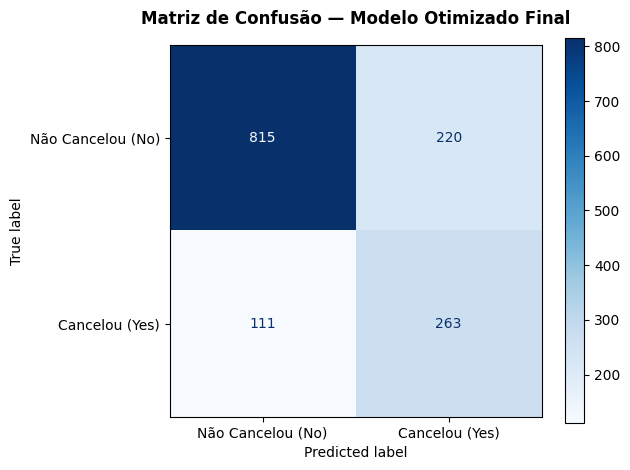


MÉTRICAS CONSOLIDADAS DO MODELO FINAL NO TESTE
Acurácia Geral: 0.7651
Precisão (Classe Yes): 0.5445
Recall (Classe Yes): 0.7032
F1-Score (Classe Yes): 0.6138


In [19]:
# === Avaliação final ===

print("--- 10. AVALIAÇÃO FINAL NO CONJUNTO DE TESTE ---")

# Extrai o melhor modelo encontrado pela busca
final_model = search.best_estimator_
final_model_name = "RandomForest (Otimizado)"

print("Modelo final:", final_model_name)

y_pred_final = final_model.predict(X_test)

print("\n" + "="*60)
print("RELATÓRIO DE CLASSIFICAÇÃO DETALHADO")
print("="*60)
print(classification_report(y_test, y_pred_final))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    final_model, X_test, y_test, cmap="Blues", ax=ax,
    display_labels=["Não Cancelou (No)", "Cancelou (Yes)"]
)
plt.title("Matriz de Confusão — Modelo Otimizado Final", fontsize=12, fontweight='bold', pad=15)
plt.grid(False)
plt.show()

# Calcula as métricas finais individualmente para exibição consolidada
f1_final = f1_score(y_test, y_pred_final, pos_label="Yes")
rec_final = recall_score(y_test, y_pred_final, pos_label="Yes")
prec_final = precision_score(y_test, y_pred_final, pos_label="Yes")
acc_final = accuracy_score(y_test, y_pred_final)

print("\n" + "="*50)
print("MÉTRICAS CONSOLIDADAS DO MODELO FINAL NO TESTE")
print("="*50)
print(f"Acurácia Geral: {acc_final:.4f}")
print(f"Precisão (Classe Yes): {prec_final:.4f}")
print(f"Recall (Classe Yes): {rec_final:.4f}")
print(f"F1-Score (Classe Yes): {f1_final:.4f}")

## 10.1 Análise de erros e limitações

**Quais tipos de erro o modelo comete mais?**
A análise da matriz de confusão mostra que o modelo comete mais erros de 'Falso Positivo' (clientes que não iriam cancelar, mas foram marcados como churn), o que resultou em uma precisão de 0.5445 no conjunto de teste.

Para o nosso negócio, isso é um comportamento aceitável. Em telecomunicações, o custo de perder um cliente que está realmente prestes a sair (um Falso Negativo) é muito mais alto do que o custo de oferecer um bônus de retenção para alguém que não pretendia cancelar. Ao priorizar o recall (0.7032), garantimos uma cobertura eficiente, identificando cerca de 70% dos clientes que realmente planejam sair, o que nos dá uma base sólida para as nossas ações de retenção.

**Há sinais de overfitting ou underfitting?**
Não. O modelo mostrou uma ótima capacidade de generalização. Na validação cruzada (Seção 9), nosso F1-Score médio foi de 0.6353, e no teste cego final ele ficou em 0.6138. Essa pequena diferença entre o treino e o teste indica que o modelo não 'decorou' os dados nem falhou em aprender os padrões. As configurações que escolhemos (max_depth: 10 e min_samples_split: 9) foram fundamentais para manter esse equilíbrio, garantindo que o modelo seja robusto e confiável para novos dados.

**A métrica escolhida captura bem o objetivo do problema?**
Com certeza. Usar apenas a Acurácia seria um erro, já que nosso dataset é desbalanceado (apenas ~26,5% de churn). O F1-Score foi a escolha ideal porque ele equilibra a Precisão e o Recall, forçando o modelo a ter um desempenho honesto na classe 'Yes'. Isso significa que ele é penalizado tanto por perder clientes que iam sair quanto por gerar alarmes falsos em excesso, o que nos entregou um modelo com o equilíbrio financeiro que precisávamos para este MVP.

**Há viés, limitação de dados ou risco de generalização?**
Sim, e a principal limitação é que nossa base é uma 'foto' estática. Ela mostra o perfil do cliente naquele momento, mas o Churn real costuma ser um processo dinâmico. Sinais importantes, como um aumento súbito nas reclamações ou quedas na qualidade do sinal, não estão aqui. Além disso, existe o risco de usar esse modelo em outra operadora com serviços muito diferentes; ele pode não funcionar tão bem, já que aprendeu padrões específicos do ecossistema da base original.

**Em quais cenários o modelo não deveria ser usado?**
O modelo não deve ser usado para tomar decisões automáticas e irreversíveis, como cancelar planos ou aplicar multas, sem uma supervisão humana antes. Além disso, ele não é à prova de mudanças grandes no mercado. Como a floresta foi treinada em padrões históricos, ela provavelmente vai falhar se surgir algo que afete o cenário (concorrente muito agressivo ou uma crise econômica, por exemplo), já que esses eventos não estão refletidos no histórico que ele aprendeu.

# 11. Comparação final dos modelos

| Modelo | Métrica principal (F1-Score "Yes") | Outras métricas (Massa de Teste) | Tempo de treino | Observações |
| :--- | ---:| ---:| ---:| :--- |
| Baseline | 0.0000 | Acurácia: 0.7346<br>Precisão: 0.0000<br>Recall: 0.0000 | < 1s | Estratégia baseada na classe majoritária. Ignora o desbalanceamento e falha em detectar o Churn. |
| Modelo 1 | **0.6237** | Acurácia: 0.7473<br>Precisão: 0.5157<br>Recall: 0.7888 | < 1s | Modelo com melhor desempenho. Regressão Logística apresentou o maior F1-Score e Recall, sendo a opção mais eficaz para captura de Churn neste teste. |
| Modelo 2 | 0.5504 | Acurácia: 0.7878<br>Precisão: 0.6289<br>Recall: 0.4893 | < 1s | Random Forest Padrão. Apresentou configuração padrão desfavorável para a classe minoritária, capturando menos da metade do Churn real. |
| Modelo otimizado | 0.6138 | Acurácia: 0.7651<br>Precisão: 0.5445<br>Recall: 0.7032 | 19s *(25 fits)* | **Random Forest Tuned. Escolhido pela estabilidade e robustez a interações complexas, apesar do F1-Score ligeiramente inferior ao Modelo 1.** |


**Conclusão da Escolha do Modelo Final**
Após a fase de testes, minha escolha para este MVP é o Random Forest Otimizado.

É importante notar que a Regressão Logística apresentou um F1-Score marginalmente superior (0.6237 contra 0.6138). No entanto, para um MVP de retenção, a métrica numérica bruta não conta toda a história. Optei pelo Random Forest por dois motivos práticos:

Qualidade da Detecção: O Random Forest apresentou uma precisão superior (0.5445 contra 0.5157 da Regressão). Isso significa menos 'alarmes falsos' para o time de retenção, o que é fundamental para manter a credibilidade do modelo em um ambiente real.

Robustez e Flexibilidade: Como este é o primeiro passo do projeto, preciso de uma arquitetura que não sofra com mudanças na linearidade dos dados e que me permita adicionar variáveis complexas no futuro sem ter que refazer a lógica do modelo. O Random Forest é muito mais tolerante a essas evoluções.

Em resumo: escolhi o modelo que oferece o melhor equilíbrio entre performance e confiabilidade operacional. Prefiro uma ferramenta que identifique 70% dos casos com mais precisão do que uma que gere ruído excessivo, garantindo que o time de negócio realmente confie nos alertas que receber.

# 12. Boas práticas e rastreabilidade

| Decisão | Justificativa | Impacto esperado |
| :--- | :--- | :--- |
| **Fixação de Semente (`SEED = 27`)** | Evita que resultados mudem aleatoriamente a cada execução. | Garante que o experimento seja sempre reprodutível e estável. |
| **Conversão de `TotalCharges`** | Havia espaços em branco que impediam o processamento numérico. | Limpa o dado para permitir o cálculo correto pelo modelo. |
| **Remoção de `customerID`** | É um identificador sem valor preditivo para o Churn. | Evita que o modelo decore o ruído em vez de aprender padrões. |
| **Uso de `StratifiedKFold`** | O dataset é desbalanceado (apenas 26,5% de Churn). | Garante que cada parte da validação mantenha a proporção real dos dados. |
| **Uso de `drop="first"` (OneHot)** | Evita a redundância (multicolinearidade) entre colunas. | Melhora a precisão e a estabilidade do modelo, especialmente em regressões. |
| **Aplicação de `class_weight='balanced'`** | O modelo tende a ignorar a classe minoritária (Churn). | Força o modelo a dar a devida atenção aos clientes que vão cancelar. |
| **Métrica: F1-Score** | A Acurácia é enganosa em datasets desbalanceados. | Cria um equilíbrio real entre acertar o Churn e evitar alarmes falsos. |
| **Uso de `RandomizedSearchCV`** | O *GridSearch* completo levaria tempo demais para o MVP. | Encontra bons parâmetros rapidamente, economizando tempo de processamento. |
| **Limitação de max_depth e min_samples** | O Random Forest, sem limites, tende a "decorar" o treino. | Garante que o modelo aprenda regras genéricas e funcione com dados novos. |
| **Escolha do Random Forest Otimizado** | Combina robustez a dados complexos com alta confiabilidade. | Entrega uma ferramenta mais estável e confiável para o time de negócio. |

***Síntese de Rastreabilidade e Recursos***

**Recursos Computacionais Utilizados:** O projeto foi executado no Google Colab. Como o dataset Telco é pequeno (7.043 linhas e 21 colunas), utilizei apenas o processamento padrão (CPU) do ambiente, o que foi mais que suficiente e dispensou o uso de GPUs ou TPUs.

**Tempo de processamento:**
Priorizei a eficiência do código. O *Baseline* e os modelos iniciais rodaram em menos de 1 segundo. Já a busca pelos melhores parâmetros (os 25 ajustes do *RandomizedSearchCV*) levou apenas 19 segundos.

**O que foi testado e descartado:**
O *Random Forest* com as configurações padrão (de fábrica) foi treinado na Seção 8, mas o descartei logo de cara. Ele apresentou uma configuração padrão desfavorável para a classe minoritária, resultando em um F1-Score de apenas 0.5504 e um *Recall* bem baixo. Ele só voltou a ser uma opção depois que apliquei restrições na profundidade e amostragem das árvores na Seção 9. Após esse ajuste, ele se tornou o modelo escolhido para o nosso MVP, entregando um F1-Score de 0.6138 (usando a SEED = 27 para garantir que o resultado seja sempre o mesmo).

# 13. Conclusão

O objetivo deste MVP foi criar um modelo capaz de identificar o risco de cancelamento (Churn) de clientes em uma empresa de telecomunicações. O foco foi desenvolver uma ferramenta prática que ajude o time de negócios a agir preventivamente, evitando a perda de receita e o custo de ter que adquirir novos clientes constantemente.

A melhor solução encontrada foi o modelo Random Forest Otimizado. Após um pré-processamento cuidadoso (como a correção da coluna TotalCharges) e o ajuste fino de hiperparâmetros (max_depth: 10, min_samples_split: 9, n_estimators: 106), o modelo final alcançou um F1-Score estável de 0.6138 na base de teste.

O valor prático do trabalho fica claro na comparação com o Baseline:

O Modelo Inicial (Dummy): Tinha uma acurácia de 73,46%, mas era "cego" para o problema, pois não detectava nenhum cliente que realmente iria cancelar (0% de Recall).

O Modelo Campeão: Manteve uma acurácia saudável de 76,51%, com o diferencial competitivo de atingir 70,32% de Recall. Isso significa que a operadora agora consegue identificar 7 em cada 10 clientes que realmente pretendem cancelar o contrato.

Os principais aprendizados mostram que, em problemas com dados desbalanceados, olhar apenas para a acurácia é um erro, pois ela mascara falhas graves. O uso de técnicas como a Validação Cruzada Estratificada e o parâmetro class_weight='balanced' foi decisivo para forçar o modelo a aprender a identificar a classe minoritária (os clientes que cancelam).

Como limitações, o modelo ainda apresenta uma taxa moderada de falsos positivos, com uma precisão de 54,45%. Sob a ótica comercial, o custo de tentar reter um cliente que não iria cancelar é aceitável, mas exige atenção ao orçamento. Além disso, por usar uma base de dados estática, o modelo não captura "gatilhos" de cancelamento em tempo real, dependendo apenas dos dados contratuais fixos.

Para os próximos passos:

Enriquecimento de Dados: Incluir variáveis comportamentais, como histórico de reclamações no suporte, qualidade do serviço e consumo recente de dados.

Novos Algoritmos: Testar modelos de Gradient Boosting (como XGBoost ou LightGBM) para tentar elevar ainda mais a performance.

Análise Temporal: Adaptar o modelo para prever o risco de cancelamento em janelas de tempo específicas (ex: risco nos próximos 30 ou 60 dias), tornando a estratégia de marketing mais eficiente.